# Reading DICOM files: render the image + extract metadata

**Goal:** load medical-imaging **DICOM** files straight from a URL, **display the image**,
then pull the header **metadata** (plus a link back to the source file) into a `pandas`
DataFrame and **save it locally as CSV**.

**What is DICOM?** DICOM (Digital Imaging and Communications in Medicine) is the standard
format for medical images — CT, MR, X-ray, ultrasound, and more. Unlike a plain `.jpg`, a
single DICOM file bundles two things: the **pixel data** (the actual image) and a rich
**header** of tagged metadata — patient, study, series, modality, scanner, image geometry,
and hundreds of other attributes. That header is what we flatten into a table.

We use two small, public sample files from the `pydicom` project (a CT slice and an MR slice).

## Setup

If needed: `pip install pydicom numpy pandas matplotlib`

In [5]:
import urllib.request
from io import BytesIO
from pathlib import Path

!pip install pydicom numpy pandas matplotlib
import pydicom
import pandas as pd
import matplotlib.pyplot as plt

print("pydicom", pydicom.__version__)

# Public sample DICOMs (from the pydicom test suite). Swap in your own URLs or
# local file paths as needed.
DICOM_SOURCES = [
    "https://raw.githubusercontent.com/pydicom/pydicom/main/src/pydicom/data/test_files/CT_small.dcm",
    "https://raw.githubusercontent.com/pydicom/pydicom/main/src/pydicom/data/test_files/MR_small.dcm",
]

OUT = Path("dicom_metadata.csv")   # saved next to this notebook

def load_dicom(src):
    # Read a DICOM from an http(s) URL or a local path -> pydicom Dataset
    src = str(src)
    if src.startswith(("http://", "https://")):
        with urllib.request.urlopen(src) as resp:
            return pydicom.dcmread(BytesIO(resp.read()))
    return pydicom.dcmread(src)

# Load once, reuse for both rendering and metadata extraction
datasets = [(src, load_dicom(src)) for src in DICOM_SOURCES]
print("loaded", len(datasets), "DICOM files")

pydicom 3.0.1
loaded 2 DICOM files


## Step 1 — Render the images

The pixel data lives in `ds.pixel_array` (a NumPy array). Medical images are typically
grayscale, so we display them with a gray colormap.

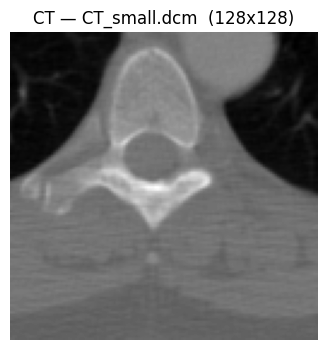

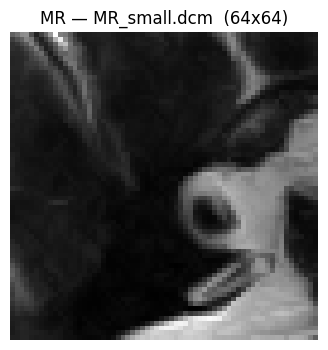

In [6]:
def show_dicom(ds, title=""):
    plt.figure(figsize=(4, 4))
    plt.imshow(ds.pixel_array, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

for src, ds in datasets:
    filename = src.split("/")[-1]
    show_dicom(ds, f"{ds.get('Modality', '?')} — {filename}  ({ds.Rows}x{ds.Columns})")

## Step 2 — Extract metadata (+ a link to the source) into a DataFrame

We pull a useful subset of header tags. `ds.get("Tag", None)` is used throughout so a
missing tag becomes `None` instead of raising. Each row also keeps the **`source_url`**
so every record links back to the file it came from.

In [7]:
# A clinically useful subset of DICOM tags (add or remove as you like)
TAGS = [
    "Modality", "PatientID", "PatientName", "PatientSex", "PatientAge",
    "StudyDate", "StudyDescription", "SeriesDescription", "BodyPartExamined",
    "Manufacturer", "ManufacturerModelName",
    "Rows", "Columns", "SliceThickness", "PhotometricInterpretation",
    "BitsAllocated", "StudyInstanceUID", "SeriesInstanceUID", "SOPInstanceUID",
]

def extract_metadata(ds, source_url):
    row = {"source_url": source_url, "filename": source_url.split("/")[-1]}
    for tag in TAGS:
        val = ds.get(tag, None)
        row[tag] = str(val) if val is not None else None
    # a couple of fields that need special handling
    ps = ds.get("PixelSpacing", None)
    row["PixelSpacing"] = str(list(ps)) if ps is not None else None
    row["TransferSyntax"] = str(getattr(ds.file_meta, "TransferSyntaxUID", None))
    return row

df = pd.DataFrame([extract_metadata(ds, src) for src, ds in datasets])
df

,source_url,filename,Modality,PatientID,PatientName,PatientSex,PatientAge,StudyDate,StudyDescription,SeriesDescription,...,Rows,Columns,SliceThickness,PhotometricInterpretation,BitsAllocated,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,PixelSpacing,TransferSyntax
0,https://raw.githubusercontent.com/pydicom/pydi...,CT_small.dcm,CT,1CT1,CompressedSamples^CT1,O,000Y,20040119,e+1,None,...,128,128,5.000000,MONOCHROME2,16,1.3.6.1.4.1.5962.1.2.1.20040119072730.12322,1.3.6.1.4.1.5962.1.3.1.1.20040119072730.12322,1.3.6.1.4.1.5962.1.1.1.1.1.20040119072730.12322,"['0.661468', '0.661468']",1.2.840.10008.1.2.1
1,https://raw.githubusercontent.com/pydicom/pydi...,MR_small.dcm,MR,4MR1,CompressedSamples^MR1,F,None,20040826,None,None,...,64,64,0.8000,MONOCHROME2,16,1.3.6.1.4.1.5962.1.2.4.20040826185059.5457,1.3.6.1.4.1.5962.1.3.4.1.20040826185059.5457,1.3.6.1.4.1.5962.1.1.4.1.1.20040826185059.5457,"['0.3125', '0.3125']",1.2.840.10008.1.2.1


## Step 3 — Save the DataFrame locally as CSV

In [8]:
df.to_csv(OUT, index=False)
print(f"Wrote {OUT.resolve()}  ({len(df)} rows, {df.shape[1]} columns)")

# read it back to confirm
pd.read_csv(OUT).head()

Wrote /Users/davidlopez/Library/Application Support/Claude/local-agent-mode-sessions/edab4e8a-8f37-436c-81cb-ddb552643a37/63fcd7c8-ab49-48ff-9078-a2c9967287fc/local_17642962-1151-4965-a82e-13e83b434982/outputs/dicom_metadata.csv  (2 rows, 23 columns)


,source_url,filename,Modality,PatientID,PatientName,PatientSex,PatientAge,StudyDate,StudyDescription,SeriesDescription,...,Rows,Columns,SliceThickness,PhotometricInterpretation,BitsAllocated,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,PixelSpacing,TransferSyntax
0,https://raw.githubusercontent.com/pydicom/pydi...,CT_small.dcm,CT,1CT1,CompressedSamples^CT1,O,000Y,20040119,e+1,NaN,...,128,128,5.0,MONOCHROME2,16,1.3.6.1.4.1.5962.1.2.1.20040119072730.12322,1.3.6.1.4.1.5962.1.3.1.1.20040119072730.12322,1.3.6.1.4.1.5962.1.1.1.1.1.20040119072730.12322,"['0.661468', '0.661468']",1.2.840.10008.1.2.1
1,https://raw.githubusercontent.com/pydicom/pydi...,MR_small.dcm,MR,4MR1,CompressedSamples^MR1,F,NaN,20040826,NaN,NaN,...,64,64,0.8,MONOCHROME2,16,1.3.6.1.4.1.5962.1.2.4.20040826185059.5457,1.3.6.1.4.1.5962.1.3.4.1.20040826185059.5457,1.3.6.1.4.1.5962.1.1.4.1.1.20040826185059.5457,"['0.3125', '0.3125']",1.2.840.10008.1.2.1


### Notes for the seminar

- A DICOM file = **pixel data + a tagged metadata header**; here we used both.
- `ds.pixel_array` requires **NumPy**. Some DICOMs are **compressed** (JPEG/JPEG2000) and
  need an extra plugin (`pylibjpeg` or `python-gdcm`) before the pixels can be decoded —
  these small samples are uncompressed, so no plugin is needed.
- The header carries **PHI** (patient name, ID, dates). For real scans you would add a
  **de-identification** step (blank or hash those tags) before sharing — ask if you want
  that added.
- In practice, images live in a hospital **PACS** and are retrieved via DICOM networking;
  the file-based workflow shown here is the common starting point for analysis.